[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/adnanaltimeemy/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
/var/folders/88/w4w1n8l12kd_z42_6mrnndmw0000gn/T/ipykernel_5353/1418191192.py:22: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  text_cols = df.select_dtypes(include="object").columns


                                 event_name         event_date  \
0  UFC Fight Night: Grasso vs. Shevchenko 2  September 16 2023   
1  UFC Fight Night: Grasso vs. Shevchenko 2  September 16 2023   
2  UFC Fight Night: Grasso vs. Shevchenko 2  September 16 2023   
3  UFC Fight Night: Grasso vs. Shevchenko 2  September 16 2023   
4  UFC Fight Night: Grasso vs. Shevchenko 2  September 16 2023   

           event_location       Weight class              fighter1  \
0  Las Vegas, Nevada, USA  Women's Flyweight          Alexa Grasso   
1  Las Vegas, Nevada, USA       Welterweight  Jack Della Maddalena   
2  Las Vegas, Nevada, USA       Bantamweight        Raul Rosas Jr.   
3  Las Vegas, Nevada, USA        Lightweight      Daniel Zellhuber   
4  Las Vegas, Nevada, USA      Featherweight           Kyle Nelson   

               fighter2   outcome                                    Kd  \
0  Valentina Shevchenko      Draw  1                                  0   
1         Kevin Holland  fighter

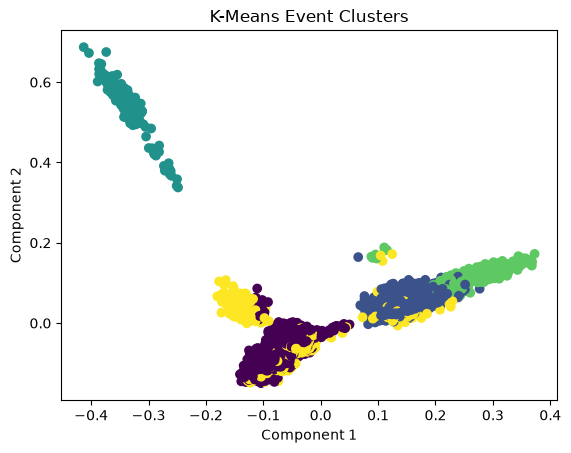


Saved as events_clustered.csv


In [1]:
# Install if needed:
# !pip install pandas scikit-learn nltk matplotlib

import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

nltk.download("stopwords")

# 1. Load dataset
df = pd.read_csv("events_raw.csv")
print(df.head())
print(df.columns)

# 2. Combine all text columns
text_cols = df.select_dtypes(include="object").columns
df["text"] = df[text_cols].fillna("").agg(" ".join, axis=1)

# 3. NLP text cleaning
stop = set(stopwords.words("english"))

def clean(x):
    x = re.sub(r"[^a-zA-Z\s]", "", str(x).lower())
    return " ".join(w for w in x.split() if w not in stop)

df["clean_text"] = df["text"].apply(clean)

# 4. TF-IDF
tfidf = TfidfVectorizer(max_features=2000)
X = tfidf.fit_transform(df["clean_text"])

# 5. K-Means
k = 5
model = KMeans(n_clusters=k, random_state=42, n_init=10)
df["cluster"] = model.fit_predict(X)

# 6. Show clusters
print("\nCluster counts:")
print(df["cluster"].value_counts().sort_index())

for i in range(k):
    print(f"\nCluster {i}:")
    print(df[df["cluster"] == i]["text"].head(5).to_string(index=False))

# 7. Visualise
pca = PCA(n_components=2)
X2 = pca.fit_transform(X.toarray())

plt.scatter(X2[:, 0], X2[:, 1], c=df["cluster"])
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.title("K-Means Event Clusters")
plt.show()

# 8. Save result
df.to_csv("events_clustered.csv", index=False)
print("\nSaved as events_clustered.csv")